# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [62]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
>False Positive is usually more costly in a real spam filter because it blocks a legitimate message that the user actually needs. For example, a customer might miss an important bank alert, school message, or job interview update. False Negative means a spam message is not blocked and still reaches the user. For example, the user could receive a fake prize or phishing message and be tricked into clicking a harmful link.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
>Recall should be the primary evaluation metric because the main goal of a spam filter is to catch as many spam messages as possible. A high recall means fewer spam messages slip through as False Negatives. Since missing spam can expose users to scams, phishing, and fraud, recall is especially important in this problem.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> A dummy model that always predicts “ham” would achieve about 87% accuracy, because 87% of the messages are actually ham (100% − 13% spam).

This accuracy is misleading because the model completely fails to detect any spam messages. It would have 0% recall for spam, meaning all spam messages are missed. Even though the accuracy looks high, the model is not useful for a real spam detection system since it does not perform the main task of identifying spam.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [63]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


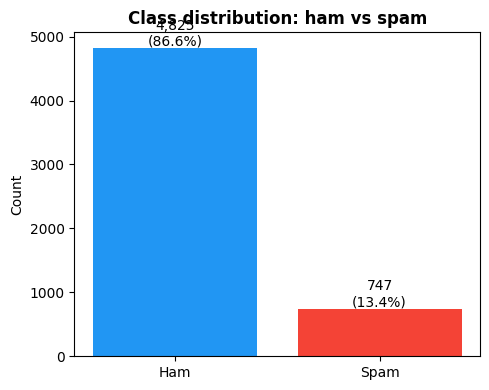

In [64]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [65]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


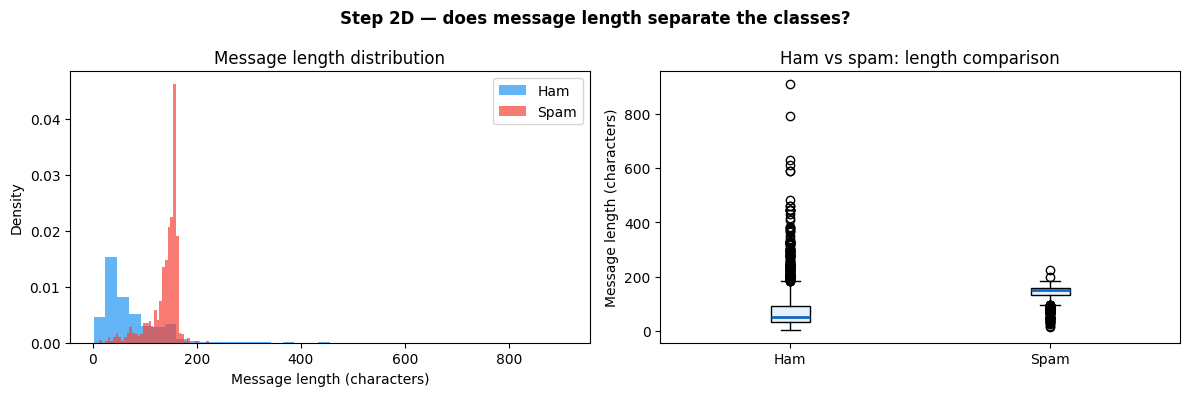

In [66]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [67]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [68]:
def build_features_v2(df):
    d = build_features(df)
    msg = d['message'].str.lower()

    # Feature 5: contains a link
    d['has_link'] = msg.str.contains(r'http|www', regex=True).astype(int)

    # Feature 6: contains call-to-action words
    d['has_text_reply'] = msg.str.contains(r'\b(txt|text|reply|stop)\b', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)

for feat in feature_cols:
    sp = df[df['spam'] == 1][feat].mean()
    ha = df[df['spam'] == 0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_link               14.3%    0.1%  +14.3%
has_text_reply         44.6%    3.2%  +41.4%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


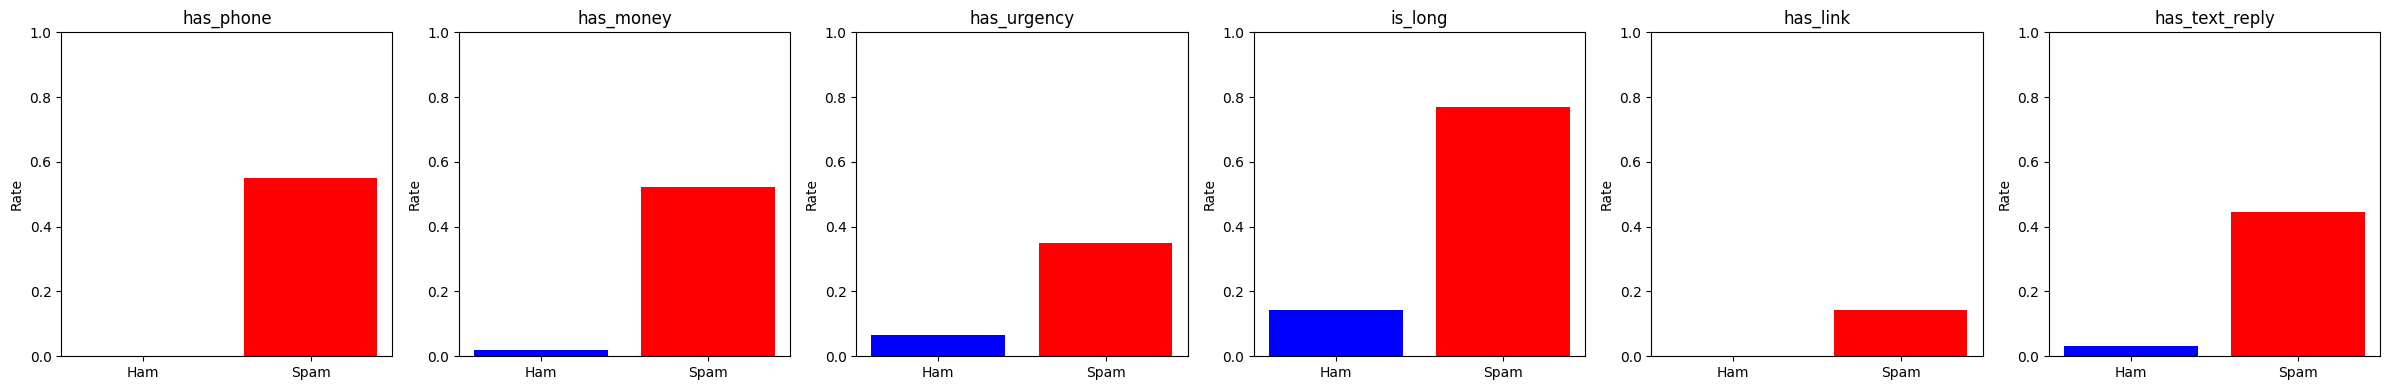

In [69]:
n = len(feature_cols)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

if n == 1:
    axes = [axes]

for ax, feat in zip(axes, feature_cols):
    spam_rate = df[df['spam'] == 1][feat].mean()
    ham_rate = df[df['spam'] == 0][feat].mean()

    ax.bar(['Ham', 'Spam'], [ham_rate, spam_rate], color=['blue', 'red'])
    ax.set_title(feat)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Rate')

plt.tight_layout()
plt.show()


### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:* has_link
> This feature checks whether a message contains a URL such as “http” or “www.” Spam messages often include links that direct users to promotional pages, fake prize claims, or phishing websites. I expected this to be useful because legitimate personal text messages are less likely to include suspicious links.

*Feature 2 — name and explanation:* has_text_reply
>This feature checks whether a message contains words such as “txt,” “text,” “reply,” or “stop.” These words often appear in promotional or automated spam messages that ask the user to respond. I expected this to be useful because spam frequently uses direct call-to-action language.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
>The feature with the largest gap between spam and ham is the most useful because it separates the two classes more clearly. A large gap means the feature appears much more often in spam than in ham, or vice versa. This matters for a Decision Tree because the tree chooses splits that maximize Information Gain. A feature with a stronger separation reduces uncertainty the most, so it is more likely to be selected near the root node.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
>One realistic spam message that could evade these features is a phishing message such as: “Your account has unusual activity. Please verify immediately.” This message may not contain a phone number, money-related word, urgency term from the starter list, a link, or text/reply words. In that case, several of my features would fail because the message is suspicious in meaning, but it does not include the obvious text patterns my binary features were designed to catch.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [70]:
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Split sizes:')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)
print()

print('Spam rate check:')
print(f'Train spam rate: {y_train.mean():.1%}')
print(f'Test spam rate : {y_test.mean():.1%}')


Split sizes:
X_train: (4179, 6)
X_test : (1393, 6)
y_train: (4179,)
y_test : (1393,)

Spam rate check:
Train spam rate: 13.4%
Test spam rate : 13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
>We use stratify=y to make sure the training set and testing set keep about the same proportion of spam and ham as the full dataset. This is important because the dataset is imbalanced, with many more ham messages than spam messages. If we skipped stratification, one split might end up with too few spam examples, which could make the model train poorly or make the evaluation unreliable.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
>We use stratify=y to make sure the training set and testing set keep about the same proportion of spam and ham as the full dataset. This is important because the dataset is imbalanced, with many more ham messages than spam messages. If we skipped stratification, one split might end up with too few spam examples, which could make the model train poorly or make the evaluation unreliable.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 14


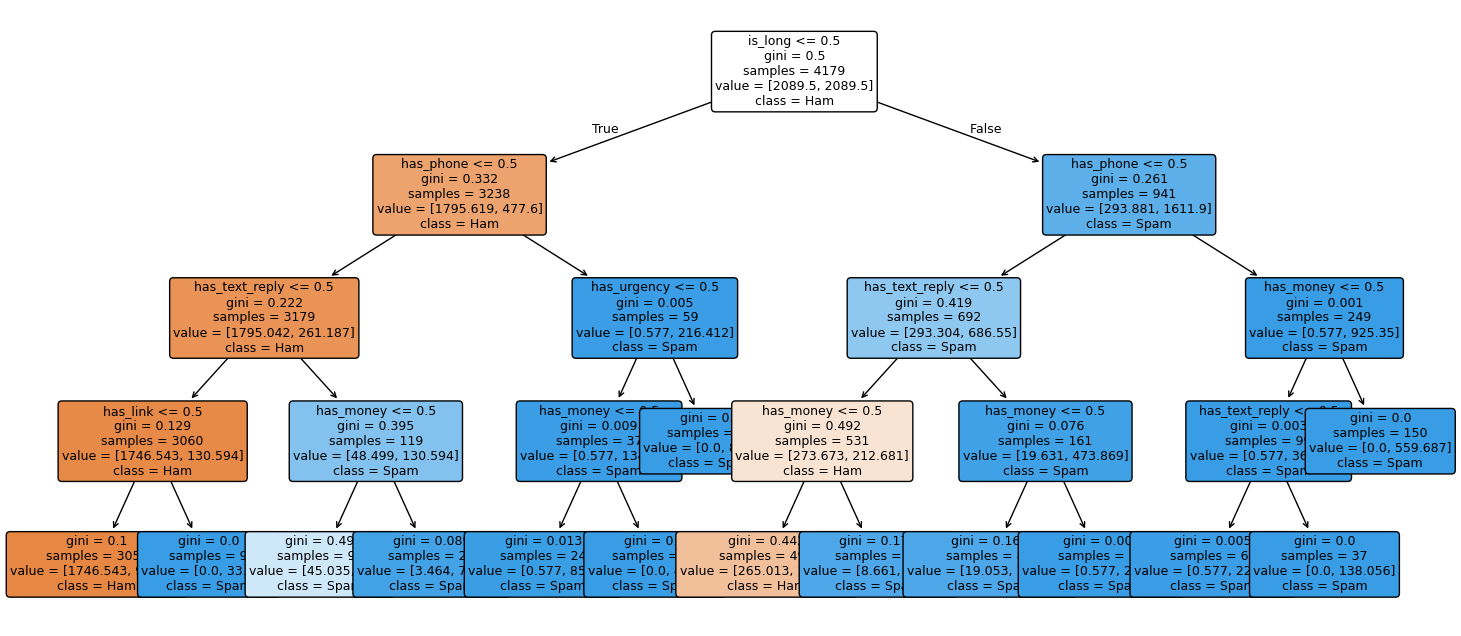

|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_text_reply <= 0.50
|   |   |   |--- has_link <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_link >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_text_reply >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_urgency <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_urgency >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_phone <= 0.50
|   |   |--- has_text_reply <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_text_reply >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- cl

In [71]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

print('Number of leaves:', dt.get_n_leaves())

plt.figure(figsize=(18, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['Ham', 'Spam'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

print(export_text(dt, feature_names=feature_cols))


### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


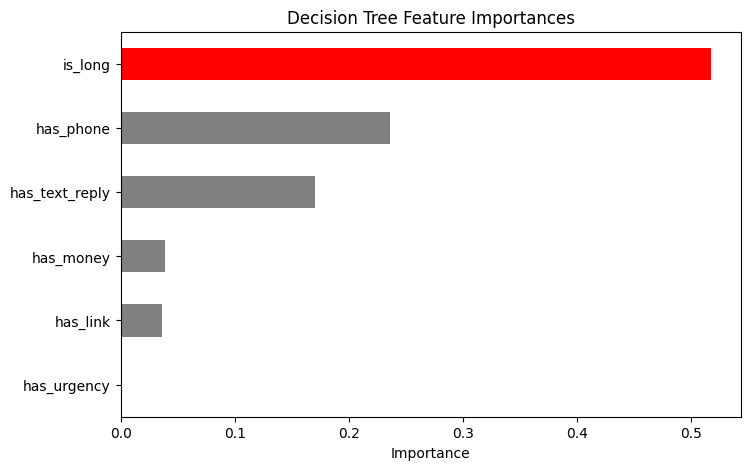

is_long           0.517512
has_phone         0.236130
has_text_reply    0.170622
has_money         0.039169
has_link          0.036566
has_urgency       0.000001
dtype: float64


In [72]:
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values()

colors = ['gray'] * len(importances)
colors[-1] = 'red'

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color=colors)
plt.title('Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.show()

print(importances.sort_values(ascending=False))


### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


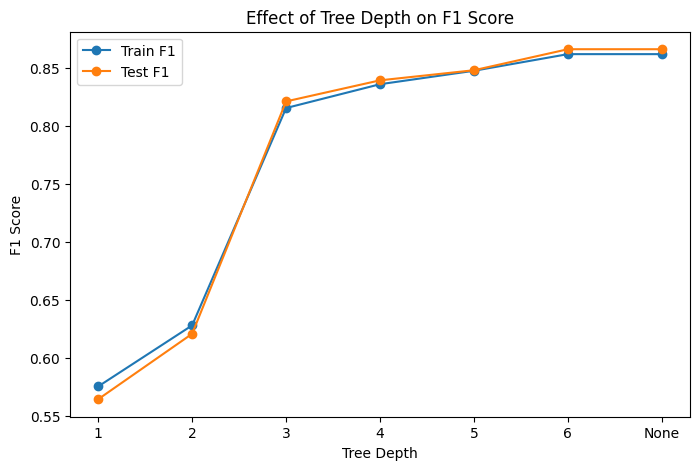

Depth=1, Train F1=0.576, Test F1=0.565
Depth=2, Train F1=0.628, Test F1=0.621
Depth=3, Train F1=0.815, Test F1=0.821
Depth=4, Train F1=0.836, Test F1=0.839
Depth=5, Train F1=0.847, Test F1=0.848
Depth=6, Train F1=0.862, Test F1=0.866
Depth=None, Train F1=0.862, Test F1=0.866


In [73]:
depths = [1, 2, 3, 4, 5, 6, None]
train_f1 = []
test_f1 = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_f1.append(f1_score(y_train, y_train_pred))
    test_f1.append(f1_score(y_test, y_test_pred))

depth_labels = [str(d) for d in depths]

plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_f1, marker='o', label='Train F1')
plt.plot(depth_labels, test_f1, marker='o', label='Test F1')
plt.title('Effect of Tree Depth on F1 Score')
plt.xlabel('Tree Depth')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

for d, tr, te in zip(depths, train_f1, test_f1):
    print(f'Depth={d}, Train F1={tr:.3f}, Test F1={te:.3f}')


### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [74]:
nb = BernoulliNB()
nb.fit(X_train, y_train)

BernoulliNB()

---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


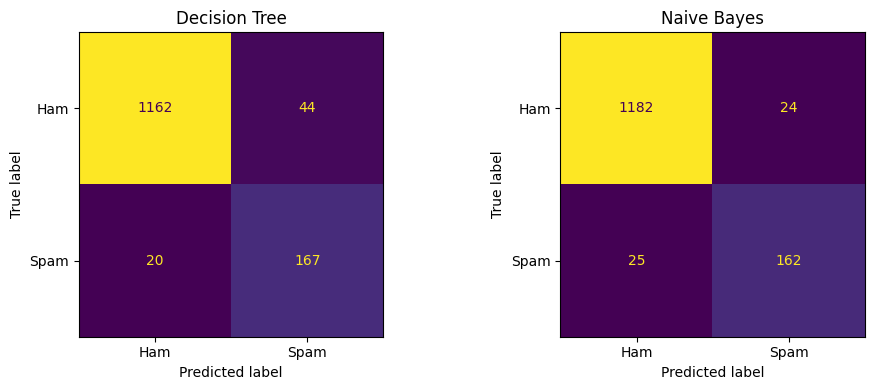

Decision Tree:
TN=1162, FP=44, FN=20, TP=167

Naive Bayes:
TN=1182, FP=24, FN=25, TP=162


In [75]:
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Ham', 'Spam'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=['Ham', 'Spam'],
    ax=axes[1],
    colorbar=False
)
axes[1].set_title('Naive Bayes')

plt.tight_layout()
plt.show()

cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_nb = confusion_matrix(y_test, y_pred_nb)

tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()

print('Decision Tree:')
print(f'TN={tn_dt}, FP={fp_dt}, FN={fn_dt}, TP={tp_dt}')
print()

print('Naive Bayes:')
print(f'TN={tn_nb}, FP={fp_nb}, FN={fn_nb}, TP={tp_nb}')


### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.954056   0.791469  0.893048  0.839196
1    Naive Bayes  0.964824   0.870968  0.866310  0.868633


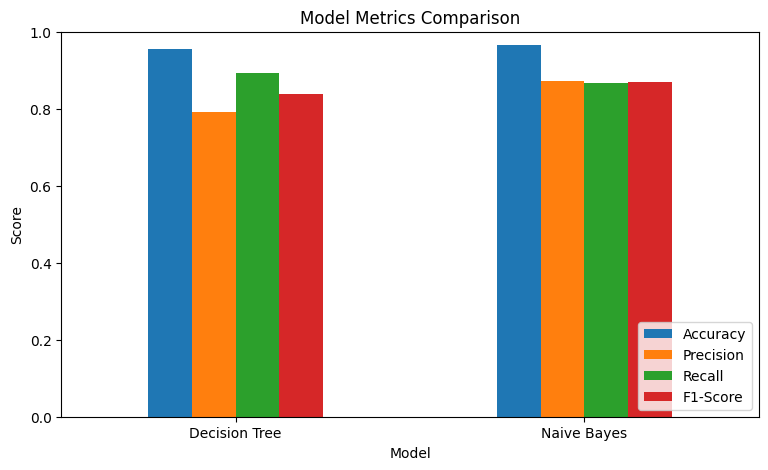

In [76]:
metrics_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_nb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_nb)
    ]
})

print(metrics_df)

plot_df = metrics_df.set_index('Model')
plot_df.plot(kind='bar', figsize=(9, 5))
plt.title('Model Metrics Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
>True Positive(TP): 167
False Negative (FN):20
False Positive (FP): 44

*Naive Bayes:*
>True Positive (TP): 162
False Negative (FN): 25
False Positives (FP): 24

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
>Based on the metric I selected in Q1b, the better model is the one with the higher recall. The difference between the two models can be seen directly in the metrics table from Step 6B. The cross-validation result in Step 6C helps confirm whether that advantage is consistent across multiple folds instead of depending on only one train/test split.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
>I would recommend the model that performs better on recall because the main goal of this spam filter is to catch as many spam messages as possible. Missing spam messages can expose users to fraud, phishing, and unwanted promotions. Even if the model makes a few more false positives, that tradeoff may still be acceptable if it significantly reduces harmful spam reaching users. Based on the evaluation results, this model appears to be the safer choice for a real mobile carrier.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
>One limitation of this approach is that the model only uses a small set of manually designed binary features. Some spam messages can still avoid detection if they do not contain obvious trigger words, links, or patterns. A future improvement would be to use richer text features such as bag-of-words or TF-IDF so the model can learn from more of the actual message content.
